In [ ]:
import pandas as pd
import numpy as np
from numpy import argmax
import matplotlib.pyplot as plt
%matplotlib inline
import librosa
import librosa.display
import IPython.display
import pandas as pd
import random
import warnings
import os
from PIL import Image
import pathlib
import csv
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/raga_recog_dataset_Phase-II.csv')

In [ ]:
df

,filename,chroma_stft,rmse,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,contrast,mel,tonnetz,mfcc1,mfcc2,mfcc3,mfcc4,mfcc5,mfcc6,mfcc7,mfcc8,mfcc9,mfcc10,mfcc11,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,mfcc21,mfcc22,mfcc23,mfcc24,mfcc25,mfcc26,mfcc27,mfcc28,mfcc29,mfcc30,mfcc31,mfcc32,mfcc33,mfcc34,mfcc35,mfcc36,mfcc37,mfcc38,mfcc39,mfcc40,label
0,song_28.mp3,0.274206,0.155100,1598.124810,1850.970943,3185.995496,0.056514,23.134254,6.264009,0.024662,-167.682816,108.983337,-22.076075,35.297249,-3.312627,0.444070,-6.939825,1.151313,-13.242552,9.098583,-7.832334,-6.213546,-9.012344,2.401376,-9.850040,-3.043397,-10.177035,1.358721,-7.357073,0.422068,-4.691611,-4.403484,-6.671139,-1.334601,-5.797785,-0.656703,-3.552661,-1.206563,-6.073332,-2.044290,-7.326188,-0.644316,2.161919,5.415533,3.520072,7.160343,5.209234,2.723176,2.225262,1.659635,Anandabhairavi
1,song_27.mp3,0.215429,0.525738,1505.879504,1893.770914,2843.201399,0.051371,22.574448,72.820206,0.019200,-60.983105,115.202065,-8.599236,27.822208,1.163367,-14.807601,-7.422687,-3.146727,-21.509050,-0.999473,-11.504626,-3.512163,-1.865144,-1.851349,-5.267570,-3.548113,-5.820648,2.801030,-4.150241,-3.198728,-6.362967,-7.500464,-6.631664,-1.590041,-4.467941,-3.824237,-4.983335,-1.952609,-1.942388,5.233437,5.716955,10.514295,9.462333,7.703338,3.535779,3.848125,4.156825,5.969550,2.446384,1.250155,Anandabhairavi
2,song_29.mp3,0.237845,0.672849,1784.991408,2069.266018,3533.476157,0.054747,21.043100,120.541473,0.005213,-16.560774,98.302727,-13.709867,24.726294,-3.036094,-8.435711,-3.636306,-3.557181,-12.880523,-3.016002,-11.143339,-7.143221,-4.788669,-1.801925,-2.607754,1.248317,-0.611403,1.200247,-3.187017,-1.650672,-2.759074,-2.184091,-4.163511,-1.220172,-3.822064,-1.149249,-3.233911,-2.068057,-0.826490,4.066833,7.391893,10.889918,9.528884,7.795704,4.569308,5.203630,3.601874,5.444336,4.154684,3.132570,Anandabhairavi
3,song_7.mp3,0.303620,0.057367,1453.941696,1170.692650,2516.129165,0.105633,28.883067,0.887843,0.060824,-247.455521,137.145737,-75.109200,15.418835,-24.910748,-25.454830,-35.614925,-44.455936,-9.132675,-10.896485,-6.559312,-26.874365,-21.379980,1.582419,-1.183431,-7.866126,-14.687433,-2.191859,-9.260876,-3.560874,3.012328,-14.379135,-1.059402,-1.975005,-10.003238,-10.502950,-8.396460,6.148086,0.302269,0.065898,0.011451,-6.735325,-4.049429,-5.591233,-1.608224,-4.688880,-4.201306,2.607306,-1.974147,-2.727457,Anandabhairavi
4,song_26.mp3,0.215570,0.204862,1188.483301,1531.778305,2042.186239,0.051179,23.649567,10.602968,-0.012334,-141.688767,142.539398,-10.551584,16.046398,-26.600452,2.454040,1.861583,2.050166,-12.918335,3.886387,-1.561368,-5.311874,-11.899229,0.585678,-3.118896,-0.439662,-7.616439,-0.243282,-6.936875,-2.909155,-8.237361,-2.462110,-8.889487,-5.415492,-6.633533,6.675288,13.598409,21.168535,16.971458,15.715361,3.032575,-5.572026,-6.391319,4.366990,5.827260,2.358907,-4.803684,-3.615998,-0.058192,6.469366,Anandabhairavi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,song_25.mp3,0.223745,0.096109,1790.208198,1933.370765,3497.670802,0.063781,24.562011,3.068096,0.025297,-238.615448,90.400185,-34.539326,21.507036,-17.544773,-19.668306,-12.705247,-18.386032,-23.944073,-13.820561,-19.936552,-4.353498,-18.077129,1.842018,-0.860293,-15.093869,2.704350,-7.022518,-11.711380,-9.287390,-10.228944,-9.170725,-6.514760,-4.119253,-4.327611,1.580533,-0.234174,8.841179,-0.230228,11.624892,3.794180,7.206067,4.893110,2.775811,5.910505,5.556123,0.598006,-1.112370,-3.768898,-1.527829,Reethigowla
596,song_11.mp3,0.223745,0.096109,1790.208198,1933.370765,3497.670802,0.063781,24.562011,3.068096,0.025297,-238.615448,90.400185,-34.539326,21.507036,-17.544773,-19.668306,-12.705247,-18.386032,-23.944073,-13.820561,-19.936552,-4.353498,-18.077129,1.842018,-0.860293,-15.093869,2.704350,-7.022518

In [ ]:
df.head()

,filename,chroma_stft,rmse,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,contrast,mel,tonnetz,mfcc1,mfcc2,mfcc3,mfcc4,mfcc5,mfcc6,mfcc7,mfcc8,mfcc9,mfcc10,mfcc11,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,mfcc21,mfcc22,mfcc23,mfcc24,mfcc25,mfcc26,mfcc27,mfcc28,mfcc29,mfcc30,mfcc31,mfcc32,mfcc33,mfcc34,mfcc35,mfcc36,mfcc37,mfcc38,mfcc39,mfcc40,label
0,song_28.mp3,0.274206,0.155100,1598.124810,1850.970943,3185.995496,0.056514,23.134254,6.264009,0.024662,-167.682816,108.983337,-22.076075,35.297249,-3.312627,0.444070,-6.939825,1.151313,-13.242552,9.098583,-7.832334,-6.213546,-9.012344,2.401376,-9.850040,-3.043397,-10.177035,1.358721,-7.357073,0.422068,-4.691611,-4.403484,-6.671139,-1.334601,-5.797785,-0.656703,-3.552661,-1.206563,-6.073332,-2.044290,-7.326188,-0.644316,2.161919,5.415533,3.520072,7.160343,5.209234,2.723176,2.225262,1.659635,Anandabhairavi
1,song_27.mp3,0.215429,0.525738,1505.879504,1893.770914,2843.201399,0.051371,22.574448,72.820206,0.019200,-60.983105,115.202065,-8.599236,27.822208,1.163367,-14.807601,-7.422687,-3.146727,-21.509050,-0.999473,-11.504626,-3.512163,-1.865144,-1.851349,-5.267570,-3.548113,-5.820648,2.801030,-4.150241,-3.198728,-6.362967,-7.500464,-6.631664,-1.590041,-4.467941,-3.824237,-4.983335,-1.952609,-1.942388,5.233437,5.716955,10.514295,9.462333,7.703338,3.535779,3.848125,4.156825,5.969550,2.446384,1.250155,Anandabhairavi
2,song_29.mp3,0.237845,0.672849,1784.991408,2069.266018,3533.476157,0.054747,21.043100,120.541473,0.005213,-16.560774,98.302727,-13.709867,24.726294,-3.036094,-8.435711,-3.636306,-3.557181,-12.880523,-3.016002,-11.143339,-7.143221,-4.788669,-1.801925,-2.607754,1.248317,-0.611403,1.200247,-3.187017,-1.650672,-2.759074,-2.184091,-4.163511,-1.220172,-3.822064,-1.149249,-3.233911,-2.068057,-0.826490,4.066833,7.391893,10.889918,9.528884,7.795704,4.569308,5.203630,3.601874,5.444336,4.154684,3.132570,Anandabhairavi
3,song_7.mp3,0.303620,0.057367,1453.941696,1170.692650,2516.129165,0.105633,28.883067,0.887843,0.060824,-247.455521,137.145737,-75.109200,15.418835,-24.910748,-25.454830,-35.614925,-44.455936,-9.132675,-10.896485,-6.559312,-26.874365,-21.379980,1.582419,-1.183431,-7.866126,-14.687433,-2.191859,-9.260876,-3.560874,3.012328,-14.379135,-1.059402,-1.975005,-10.003238,-10.502950,-8.396460,6.148086,0.302269,0.065898,0.011451,-6.735325,-4.049429,-5.591233,-1.608224,-4.688880,-4.201306,2.607306,-1.974147,-2.727457,Anandabhairavi
4,song_26.mp3,0.215570,0.204862,1188.483301,1531.778305,2042.186239,0.051179,23.649567,10.602968,-0.012334,-141.688767,142.539398,-10.551584,16.046398,-26.600452,2.454040,1.861583,2.050166,-12.918335,3.886387,-1.561368,-5.311874,-11.899229,0.585678,-3.118896,-0.439662,-7.616439,-0.243282,-6.936875,-2.909155,-8.237361,-2.462110,-8.889487,-5.415492,-6.633533,6.675288,13.598409,21.168535,16.971458,15.715361,3.032575,-5.572026,-6.391319,4.366990,5.827260,2.358907,-4.803684,-3.615998,-0.058192,6.469366,Anandabhairavi


In [ ]:
df = df.drop(['filename'],axis=1)

In [ ]:
dataset = df.values
dataset

array([[0.274206281, 0.155099511, 1598.12481, ..., 2.2252616880000002,
        1.659635425, 'Anandabhairavi'],
       [0.21542909699999999, 0.52573812, 1505.879504, ..., 2.446383715,
        1.250154734, 'Anandabhairavi'],
       [0.237844571, 0.672849238, 1784.9914079999999, ..., 4.154684067,
        3.1325695510000005, 'Anandabhairavi'],
       ...,
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -3.768898249,
        -1.5278289319999998, 'Reethigowla'],
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -3.768898249,
        -1.5278289319999998, 'Reethigowla'],
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -3.768898249,
        -1.5278289319999998, 'Reethigowla']], dtype=object)

In [ ]:
X = dataset[:,0:49]

In [ ]:
X

array([[0.274206281, 0.155099511, 1598.12481, ..., 2.7231762410000004,
        2.2252616880000002, 1.659635425],
       [0.21542909699999999, 0.52573812, 1505.879504, ...,
        5.969550132999999, 2.446383715, 1.250154734],
       [0.237844571, 0.672849238, 1784.9914079999999, ...,
        5.4443364139999995, 4.154684067, 3.1325695510000005],
       ...,
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -1.112370133,
        -3.768898249, -1.5278289319999998],
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -1.112370133,
        -3.768898249, -1.5278289319999998],
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -1.112370133,
        -3.768898249, -1.5278289319999998]], dtype=object)

In [ ]:
Y = dataset[:,49]
Y

array(['Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi', 'Atana',
       'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana',
       'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana',
       'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana',
       'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana',
       'Atana', 'Bageda', 'Bageda', 'Bageda', 'Bageda', 'Bageda',
       'Bageda', 'Bageda', 'Bageda'

In [ ]:
genre_list = df.iloc[:, 49]
encoder = LabelEncoder()
Y = encoder.fit_transform(genre_list)

In [ ]:
Y

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7

In [ ]:
print(len(X))
print(len(Y))

600
600


In [ ]:
from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X)

In [ ]:
X_scale

array([[0.32800961, 0.20729576, 0.504694  , ..., 0.43929282, 0.55627028,
        0.50457247],
       [0.09501565, 0.73772514, 0.46742032, ..., 0.59070173, 0.56410805,
        0.48507208],
       [0.18387105, 0.94825922, 0.58020142, ..., 0.56620608, 0.62465953,
        0.5747169 ],
       ...,
       [0.12798066, 0.12287359, 0.58230938, ..., 0.26040525, 0.34380458,
        0.35277825],
       [0.12798066, 0.12287359, 0.58230938, ..., 0.26040525, 0.34380458,
        0.35277825],
       [0.12798066, 0.12287359, 0.58230938, ..., 0.26040525, 0.34380458,
        0.35277825]])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X_scale, Y, test_size=0.2)

In [ ]:
print (X_train)
print(len(X_train))

[[0.18616852 0.12735861 0.90995224 ... 0.14313307 0.08992784 0.28999789]
 [0.32974918 0.45643874 0.32666731 ... 0.70512703 0.62339013 0.75689493]
 [0.30679054 0.05817889 0.47397539 ... 0.52314725 0.64485538 0.67750477]
 ...
 [0.2585578  0.13558599 0.08261968 ... 0.13602616 0.37129231 0.39194366]
 [0.12798066 0.12287359 0.58230938 ... 0.26040525 0.34380458 0.35277825]
 [0.20391896 0.1413218  0.90454192 ... 0.10862598 0.14051175 0.17691565]]
480


In [ ]:
print (X_val_and_test)
print(len(X_val_and_test ))

[[0.19871786 0.10390969 0.91813698 ... 0.20763323 0.22812436 0.23698031]
 [0.80894906 0.22919815 0.27895316 ... 0.68755008 0.61170547 0.44712741]
 [0.23638171 0.13964746 0.86672457 ... 0.27589866 0.21657694 0.2145932 ]
 ...
 [0.19871786 0.10390969 0.91813698 ... 0.20763323 0.22812436 0.23698031]
 [0.40884085 0.28322923 0.26699749 ... 0.28145875 0.4900344  0.40697796]
 [0.28147993 0.16097858 0.86649624 ... 0.15516316 0.15878942 0.24246355]]
120


In [ ]:
print (Y_train)
print(len(X_val_and_test ))

[14 13 10 11  4  2  7 14  6 17 19 13 10 11  5 12 12 10 14 19 13 19 15  7
 14 10 12  6  0  1 13 12  3  2  2 16 13  5 13 15 14  0 10  1  0  9 15  0
 13  0  7 18  6  1  6 10  4 18 11 19 10 17 17 17 12  3 13 12 17  8  5  0
 10  1 12 18 17 13 10  2 11  3  4  4  5  0 15 12 10 11 11  3  1  1  6 12
  6 18 16  1 10 17  5  1 15  9  5 14  6  1 18 14  0  6 16  7  2 12 19  8
  9  0  5 10  5  4 18  8  7  4 12 16 10  8 19 13 13  9 17  3 13  6 11  4
  1  4  4  9  3 13 19  5  5  3  9 11  3 17 17  7 18 15 17  6 18  9  4  5
 16 12  1  6 16  2 16 13 10 14  6 14  2 10  8 17  8 16  0  7  3  9 17  4
 17  5 14  4 12  7 14 13  3  2  3  8 12 12  1 17  1  1 11 14  0  5 18  4
  9  4 16 14 12 10 10  9  3 15 19 17 19  7  9  8  2  5 18  8 15 18  3 14
 10 19  2  4 18 16  9  4  7  5  9 10  9  9  8 19  0 15  6  5  1  3  8 19
  4  3  3 13 16 14  5  9  8 13 18  7  2  7  8  9  0 13  2  8 14 16 18 12
 16 16  7  6  6 17  7 18 18  5  2  1 18 16 14  3  8  1 13  2 15 10 15  9
  1  5  4 19 16  8  0  8 19 15  6 18  3  7  6 11  8

In [ ]:
print (Y_val_and_test)
print(len(X_val_and_test ))

[ 6  3 15  6 12  7 17  2  0 17  6  6  9 18  8  6  5  8 15  7  2 11 14 16
 13  3  2  4  2  3 11 17 19 19 11 18 12 14  5 13  1  7 19  4 17 11  8 14
 13 19  9 13 16 11  2 11 11 18  3  7 10  0 14  6  9 11 12  3 19 15  0 16
  2  2  0 14  1 11  9 16  7 11 16 18  6  2 13 19  8 10 15  6 10 14 13  2
 16 16 17  3 11  3  8 11  1 14  2  4  5  6  1 19  0 15 15 12 12  6 18 17]
120


In [ ]:
X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.5)

In [ ]:
print(len(X_val))
print(len(X_test))
print(len(Y_val))
print(len(Y_test ))

60
60
60
60


In [ ]:
print(X_train.shape, X_val.shape, X_test.shape, Y_train.shape, Y_val.shape, Y_test.shape)

(480, 49) (60, 49) (60, 49) (480,) (60,) (60,)


simple Neural Netwoek

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential([
                    Dense(32, activation='relu', input_shape=(49,)),
                    Dense(32, activation='relu'),
                    Dense(20, activation='sigmoid')
])

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 32)                1600      
_________________________________________________________________
dense_4 (Dense)              (None, 32)                1056      
_________________________________________________________________
dense_5 (Dense)              (None, 20)                660       
Total params: 3,316
Trainable params: 3,316
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
import keras
from matplotlib import pyplot as plt
history = model.fit(X_train, Y_train, batch_size=10, epochs=200, validation_data=(X_val, Y_val))


Epoch 1/200
48/48 [==============================] - 0s 4ms/step - loss: 0.0051 - accuracy: 0.9958 - val_loss: 5.1291 - val_accuracy: 0.7000
Epoch 2/200
48/48 [==============================] - 0s 3ms/step - loss: 0.0057 - accuracy: 0.9979 - val_loss: 5.1618 - val_accuracy: 0.7000
Epoch 3/200
48/48 [==============================] - 0s 2ms/step - loss: 0.0058 - accuracy: 0.9979 - val_loss: 5.1697 - val_accuracy: 0.7000
Epoch 4/200
48/48 [==============================] - 0s 2ms/step - loss: 0.0053 - accuracy: 0.9979 - val_loss: 5.1636 - val_accuracy: 0.7000
Epoch 5/200
48/48 [==============================] - 0s 3ms/step - loss: 0.0054 - accuracy: 0.9979 - val_loss: 5.1686 - val_accuracy: 0.7000
Epoch 6/200
48/48 [==============================] - 0s 2ms/step - loss: 0.0059 - accuracy: 0.9958 - val_loss: 5.1495 - val_accuracy: 0.7000
Epoch 7/200
48/48 [==============================] - 0s 3ms/step - loss: 0.0060 - accuracy: 0.9958 - val_loss: 5.1481 - val_accuracy: 0.7000
Epoch 8/200
4

In [ ]:
model.evaluate(X_test, Y_test)

2/2 [==============================] - 0s 8ms/step - loss: 5.2267 - accuracy: 0.7167


[5.2267303466796875, 0.7166666388511658]

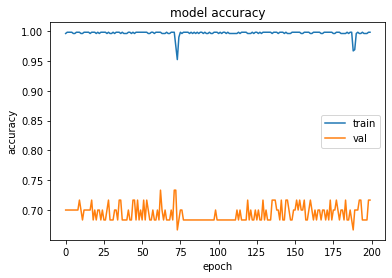

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='best')
plt.show()

LSTM

In [ ]:
import os
import librosa
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import keras
import tensorflow.keras.layers as layers
import keras
import tensorflow as tf
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Flatten
from keras.optimizers import Adam
from keras.layers import Bidirectional
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Model

In [ ]:

input_shape = (X_train.shape[1], X_train.shape[2])
model = Sequential()
adam1 = Adam(learning_rate=0.0009)
model.add(LSTM(units=128, dropout=0.05, recurrent_dropout=0.25, return_sequences=True,input_shape=input_shape))
model.add(LSTM(units=64,  dropout=0.05, recurrent_dropout=0.25, return_sequences=True))
model.add(Flatten())
model.add(Dense(units=20, activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy", optimizer=adam1, metrics=["accuracy"],)
model.summary()

Model: "sequential_30"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_7 (LSTM)                (None, 1, 128)            91136     
_________________________________________________________________
lstm_8 (LSTM)                (None, 1, 64)             49408     
_________________________________________________________________
flatten_19 (Flatten)         (None, 64)                0         
_________________________________________________________________
dense_32 (Dense)             (None, 20)                1300      
Total params: 141,844
Trainable params: 141,844
Non-trainable params: 0
_________________________________________________________________


In [ ]:
batch_size = 10 # num of training examples per minibatch
num_epochs =200
classify2 = model.fit(
    X_train,
    Y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=(X_test,Y_test),
)

Epoch 1/200
48/48 [==============================] - 4s 18ms/step - loss: 2.9943 - accuracy: 0.0538 - val_loss: 2.9940 - val_accuracy: 0.0833
Epoch 2/200
48/48 [==============================] - 0s 6ms/step - loss: 2.9859 - accuracy: 0.0881 - val_loss: 2.9857 - val_accuracy: 0.0500
Epoch 3/200
48/48 [==============================] - 0s 6ms/step - loss: 2.9629 - accuracy: 0.0828 - val_loss: 2.9473 - val_accuracy: 0.1000
Epoch 4/200
48/48 [==============================] - 0s 6ms/step - loss: 2.9072 - accuracy: 0.1509 - val_loss: 2.8272 - val_accuracy: 0.1333
Epoch 5/200
48/48 [==============================] - 0s 6ms/step - loss: 2.7914 - accuracy: 0.1419 - val_loss: 2.6209 - val_accuracy: 0.2833
Epoch 6/200
48/48 [==============================] - 0s 5ms/step - loss: 2.5718 - accuracy: 0.2309 - val_loss: 2.4104 - val_accuracy: 0.3333
Epoch 7/200
48/48 [==============================] - 0s 5ms/step - loss: 2.4379 - accuracy: 0.2912 - val_loss: 2.2889 - val_accuracy: 0.3833
Epoch 8/200


In [ ]:
model.evaluate(X_test, Y_test)

2/2 [==============================] - 1s 6ms/step - loss: 0.3940 - accuracy: 0.9167


[0.394040584564209, 0.9166666865348816]

CNN 

In [ ]:
pip install split_folders

In [ ]:
import splitfolders
# To only split into training and validation set, set a tuple to `ratio`, i.e, `(.7, .3)`.
splitfolders.ratio('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/Spec_image_dataset/', output="./data", seed=1337, ratio=(.7, .3)) # default values

Copying files: 600 files [00:03, 195.33 files/s]


In [ ]:
from keras.models import Sequential
from keras.layers.convolutional import Conv3D
from keras.layers.convolutional_recurrent import ConvLSTM2D
from keras.layers.normalization import BatchNormalization
from keras.preprocessing.image import img_to_array, array_to_img
from keras.preprocessing.image import load_img
import numpy as np
import pylab as plt

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/raga_recog_dataset_Phase-II.csv')
# Dropping unneccesary columns
data = data.drop(['filename'],axis=1)
#Encoding the Labels
raga_list = data.iloc[:, -1]
encoder = LabelEncoder()
Y = encoder.fit_transform(raga_list)
#Scaling the Feature columns
scaler = StandardScaler()
X = scaler.fit_transform(np.array(data.iloc[:, :-1], dtype = float))
#Dividing data into training and Testing set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
input_shape = (X_train.shape[1], X_train.shape[2])
X_train.shape[1], X_train.shape[2]

(1, 49)

In [ ]:
model = tf.keras.Sequential()
model.add(layers.Conv1D(64,3, activation = "relu",padding = 'same', input_shape=input_shape))
model.add(layers.Conv1D(32,3,activation = 'relu',padding = 'same'))
model.add(layers.Flatten())
model.add(layers.Dropout(0.3))
model.add(layers.Dense(64,activation = 'relu'))
model.add(layers.Dense(20,activation = 'softmax'))
model.summary()

Model: "sequential_15"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_15 (Conv1D)           (None, 1, 64)             9472      
_________________________________________________________________
conv1d_16 (Conv1D)           (None, 1, 32)             6176      
_________________________________________________________________
flatten_9 (Flatten)          (None, 32)                0         
_________________________________________________________________
dropout_16 (Dropout)         (None, 32)                0         
_________________________________________________________________
dense_18 (Dense)             (None, 64)                2112      
_________________________________________________________________
dense_19 (Dense)             (None, 20)                1300      
Total params: 19,060
Trainable params: 19,060
Non-trainable params: 0
_________________________________________________

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
classifier = model.fit(X_train, y_train,batch_size=10, epochs=200, validation_data=(X_test,y_test))

Epoch 1/200
45/45 [==============================] - 1s 6ms/step - loss: 2.9685 - accuracy: 0.0772 - val_loss: 2.8942 - val_accuracy: 0.2267
Epoch 2/200
45/45 [==============================] - 0s 3ms/step - loss: 2.7656 - accuracy: 0.2684 - val_loss: 2.7251 - val_accuracy: 0.2933
Epoch 3/200
45/45 [==============================] - 0s 3ms/step - loss: 2.5111 - accuracy: 0.2777 - val_loss: 2.4211 - val_accuracy: 0.3800
Epoch 4/200
45/45 [==============================] - 0s 3ms/step - loss: 2.0558 - accuracy: 0.4390 - val_loss: 2.0282 - val_accuracy: 0.4067
Epoch 5/200
45/45 [==============================] - 0s 3ms/step - loss: 1.7359 - accuracy: 0.5371 - val_loss: 1.7202 - val_accuracy: 0.5733
Epoch 6/200
45/45 [==============================] - 0s 3ms/step - loss: 1.4634 - accuracy: 0.5641 - val_loss: 1.5804 - val_accuracy: 0.6133
Epoch 7/200
45/45 [==============================] - 0s 3ms/step - loss: 1.2268 - accuracy: 0.6796 - val_loss: 1.4675 - val_accuracy: 0.6333
Epoch 8/200
4

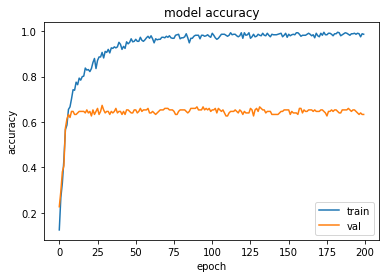

In [ ]:
history = classifier

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='best')
plt.show()

CNN-lstm

In [ ]:
def make_cnn_lstm_model(lstm_neurons,dense_neurons,drop_out):
  model = Sequential()
  model.add(Conv1D(60,32, strides=1, activation='relu',padding='causal',input_shape=(None,49,1)))
  model.add(Conv1D(80,10, strides=1, activation='relu',padding='causal'))
  model.add(TimeDistributed(Dropout(drop_out)))
  model.add(TimeDistributed(MaxPooling1D(pool_size=2)))
  model.add(TimeDistributed(Flatten()))
  model.add(LSTM(lstm_neurons))
  model.add(Dropout(drop_out)) 
  model.add(Dense(dense_neurons, activation='softmax'))
  model.add(Dense(units=20, activation="softmax"))
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model
  

In [ ]:
model_cnn_lstm = make_cnn_lstm_model(lstm_neurons= 100, dense_neurons = 100, drop_out = 0.5)
print(model_cnn_lstm.summary())

Model: "sequential_17"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_19 (Conv1D)           (None, None, 49, 60)      1980      
_________________________________________________________________
conv1d_20 (Conv1D)           (None, None, 49, 80)      48080     
_________________________________________________________________
time_distributed_19 (TimeDis (None, None, 49, 80)      0         
_________________________________________________________________
time_distributed_20 (TimeDis (None, None, 24, 80)      0         
_________________________________________________________________
time_distributed_21 (TimeDis (None, None, 1920)        0         
_________________________________________________________________
lstm_5 (LSTM)                (None, 100)               808400    
_________________________________________________________________
dropout_19 (Dropout)         (None, 100)             

In [ ]:
classifier = model.fit(X_train, y_train,batch_size=10, epochs=200, validation_data=(X_test,y_test))
# Evaluation on the test set
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))
scores = model.evaluate(X_train, y_train, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Epoch 1/200
45/45 [==============================] - 0s 4ms/step - loss: 0.0681 - accuracy: 0.9756 - val_loss: 5.2435 - val_accuracy: 0.6467
Epoch 2/200
45/45 [==============================] - 0s 3ms/step - loss: 0.0317 - accuracy: 0.9867 - val_loss: 5.2964 - val_accuracy: 0.6333
Epoch 3/200
45/45 [==============================] - 0s 2ms/step - loss: 0.0345 - accuracy: 0.9889 - val_loss: 5.3875 - val_accuracy: 0.6467
Epoch 4/200
45/45 [==============================] - 0s 3ms/step - loss: 0.0459 - accuracy: 0.9889 - val_loss: 5.4258 - val_accuracy: 0.6467
Epoch 5/200
45/45 [==============================] - 0s 3ms/step - loss: 0.0227 - accuracy: 0.9933 - val_loss: 5.5366 - val_accuracy: 0.6467
Epoch 6/200
45/45 [==============================] - 0s 3ms/step - loss: 0.0317 - accuracy: 0.9911 - val_loss: 5.5507 - val_accuracy: 0.6400
Epoch 7/200
45/45 [==============================] - 0s 3ms/step - loss: 0.0175 - accuracy: 0.9978 - val_loss: 5.5428 - val_accuracy: 0.6400
Epoch 8/200
4

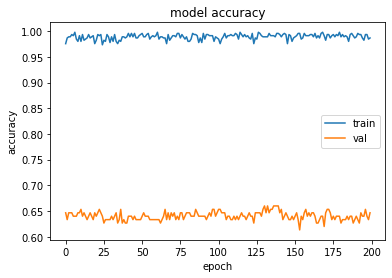

In [ ]:
history = classifier
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='best')
plt.show()